# Trend & Time-Series Analysis
FoodMatrix — Women in Data Datathon 2026 (Trade track)

How country-level trade risk for wheat/rice/maize has moved between 2010-2023,
which countries are trending up or down, and how much of the apparent trend
is real vs. a side effect of more countries getting complete coverage in
later years.

In [1]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns

sns.set_style("whitegrid")
plt.rcParams["figure.dpi"] = 110

country_risk = pd.read_csv("../data/processed/country_risk.csv")
commodity_risk = pd.read_csv("../data/processed/commodity_vulnerability.csv")

complete = country_risk[country_risk["country_risk_score"].notna()].copy()
complete_commodity = commodity_risk[commodity_risk["components_complete"]].copy()

complete.shape, complete_commodity.shape


((873, 8), (4187, 33))

## 1. Coverage over time

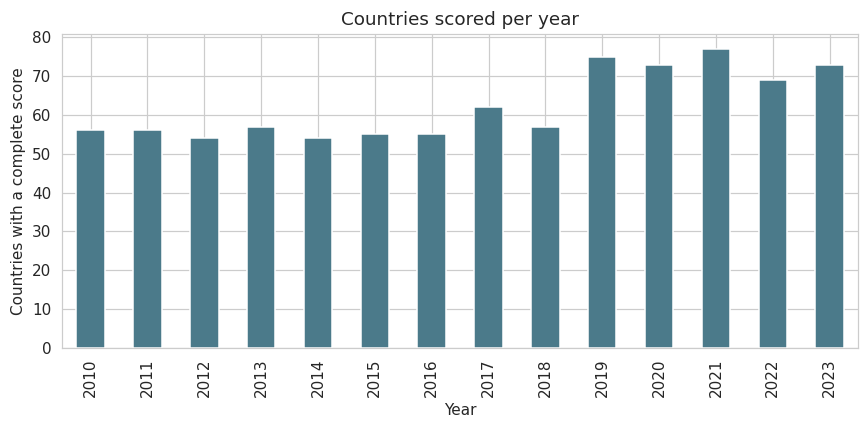

In [2]:
coverage_by_year = complete.groupby("Year")["Area_fbs"].nunique()

fig, ax = plt.subplots(figsize=(8, 4))
coverage_by_year.plot(kind="bar", ax=ax, color="#4b7a8a")
ax.set_ylabel("Countries with a complete score")
ax.set_title("Countries scored per year")
plt.tight_layout()
plt.savefig("coverage_by_year.png", dpi=150, bbox_inches="tight")
plt.show()


Coverage nearly doubles from 2010 to 2023 (56 to 73 countries). That matters
for the next section — a rising average risk score could just mean more
(and different) countries are entering the sample, not that risk itself is
rising.

## 2. Full sample vs. balanced panel

Balanced panel: 27 countries present in all 14 years


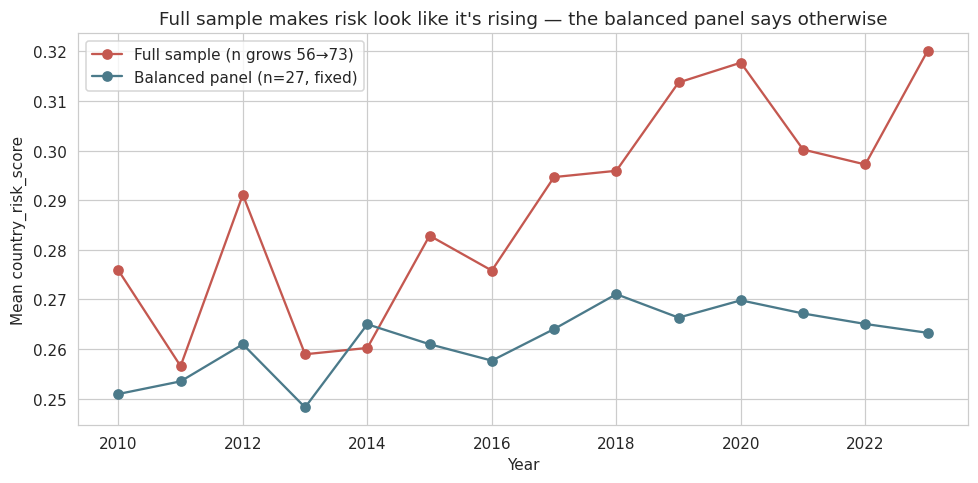

In [3]:
full_trend = complete.groupby("Year")["country_risk_score"].mean()

years_per_country = complete.groupby("Area_fbs")["Year"].nunique()
balanced_countries = years_per_country[years_per_country == 14].index
balanced = complete[complete["Area_fbs"].isin(balanced_countries)]
balanced_trend = balanced.groupby("Year")["country_risk_score"].mean()

print(f"Balanced panel: {len(balanced_countries)} countries present in all 14 years")

fig, ax = plt.subplots(figsize=(9, 4.5))
full_trend.plot(ax=ax, marker="o", label=f"Full sample (n grows 56→73)", color="#c45850")
balanced_trend.plot(ax=ax, marker="o", label=f"Balanced panel (n={len(balanced_countries)}, fixed)", color="#4b7a8a")
ax.set_ylabel("Mean country_risk_score")
ax.set_title("Full sample makes risk look like it's rising — the balanced panel says otherwise")
ax.legend()
plt.tight_layout()
plt.savefig("full_vs_balanced_trend.png", dpi=150, bbox_inches="tight")
plt.show()


Full sample: 0.276 → 0.320 (looks like a real rise). Balanced panel of the
same 27 countries every year: 0.251 → 0.263 — basically flat. Most of the
apparent increase is new (and structurally different) countries entering the
scored sample, not existing countries getting riskier. Worth stating this
explicitly if the "risk is rising" framing goes in the deck.

## 3. Trend by commodity

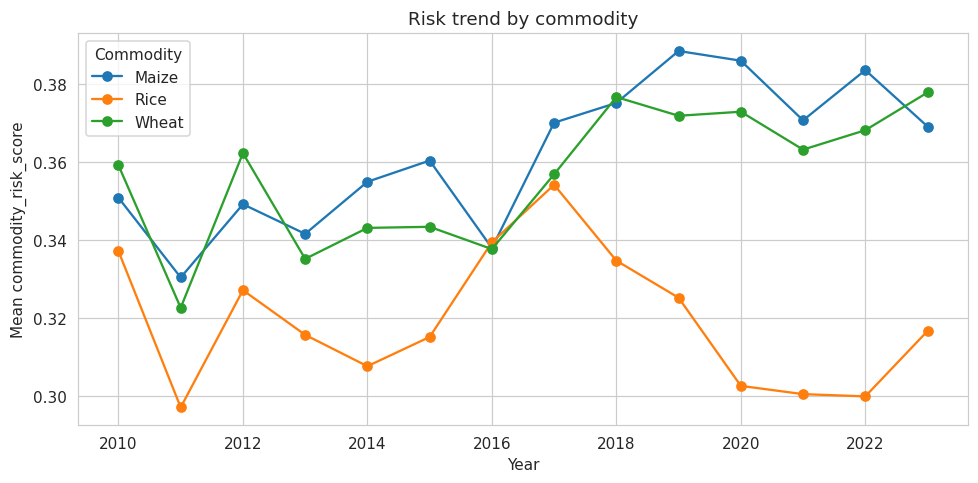

In [4]:
commodity_trend = complete_commodity.groupby(["Year", "Commodity"])["commodity_risk_score"].mean().unstack()

fig, ax = plt.subplots(figsize=(9, 4.5))
commodity_trend.plot(ax=ax, marker="o")
ax.set_ylabel("Mean commodity_risk_score")
ax.set_title("Risk trend by commodity")
plt.tight_layout()
plt.savefig("commodity_trend.png", dpi=150, bbox_inches="tight")
plt.show()


Wheat and maize sit consistently above rice across the whole period — rice
trade is less concentrated among fewer partners. All three show a mild step
up around 2017-2019 that holds through 2023, rather than a sharp
single-year jump tied to any one shock.

## 4. Biggest movers, 2010→latest available year

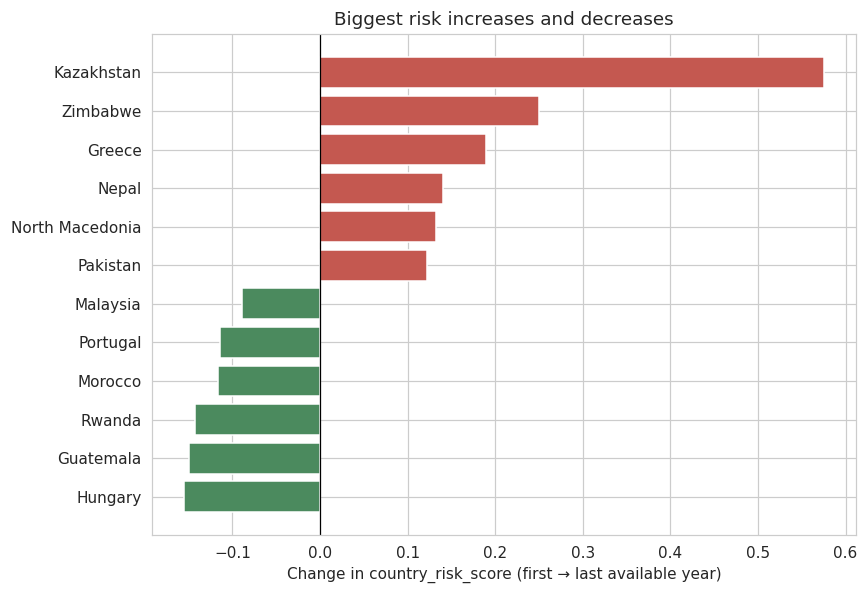

,Area_fbs,first_year,first_score,last_year,last_score,change
21,Kazakhstan,2011,0.086257,2023,0.661990,0.575733
52,Zimbabwe,2010,0.322215,2023,0.571993,0.249778
15,Greece,2010,0.051759,2023,0.241540,0.189780
30,Nepal,2010,0.242803,2022,0.383165,0.140362
32,North Macedonia,2010,0.460275,2023,0.592374,0.132099
33,Pakistan,2011,0.073952,2023,0.196641,0.122689


In [5]:
panel = complete[complete["Area_fbs"].isin(years_per_country[years_per_country >= 10].index)]

span = (
    panel.groupby("Area_fbs")
    .agg(first_year=("Year", "min"), last_year=("Year", "max"))
    .reset_index()
)

def score_at(area, year):
    row = panel[(panel["Area_fbs"] == area) & (panel["Year"] == year)]
    return row["country_risk_score"].iloc[0] if len(row) else np.nan

span["first_score"] = span.apply(lambda r: score_at(r["Area_fbs"], r["first_year"]), axis=1)
span["last_score"] = span.apply(lambda r: score_at(r["Area_fbs"], r["last_year"]), axis=1)
span["change"] = span["last_score"] - span["first_score"]

movers = pd.concat([span.nlargest(6, "change"), span.nsmallest(6, "change")])
movers = movers.sort_values("change")

fig, ax = plt.subplots(figsize=(8, 5.5))
colors = ["#c45850" if c > 0 else "#4b8a5e" for c in movers["change"]]
ax.barh(movers["Area_fbs"], movers["change"], color=colors)
ax.axvline(0, color="black", linewidth=0.8)
ax.set_xlabel("Change in country_risk_score (first → last available year)")
ax.set_title("Biggest risk increases and decreases")
plt.tight_layout()
plt.savefig("biggest_movers.png", dpi=150, bbox_inches="tight")
plt.show()

span.nlargest(6, "change")[["Area_fbs", "first_year", "first_score", "last_year", "last_score", "change"]]


Kazakhstan stands out — risk score goes from 0.09 (2011) to 0.66 (2023),
the single largest move in the panel. Zimbabwe, Greece and Nepal also trend
up meaningfully. On the other side, Hungary and Guatemala show the largest
declines. Worth a line in the deck on Kazakhstan specifically — it's the
standout story, not just a data point.

## 5. Volatility — which countries swing the most year to year

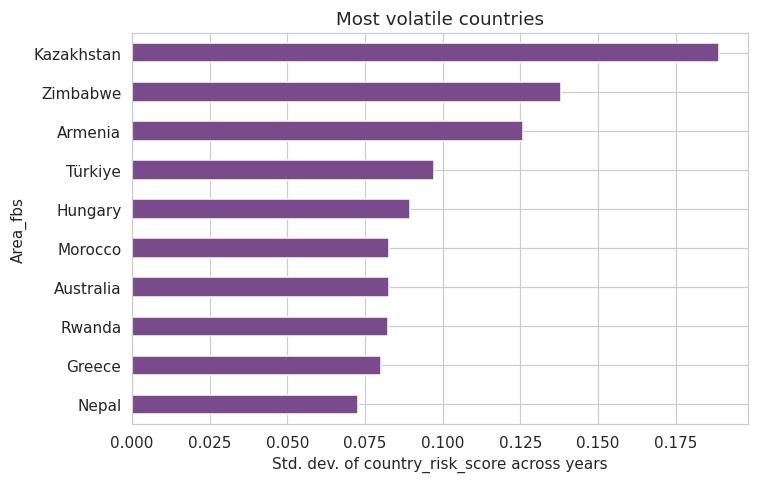

In [6]:
volatility = panel.groupby("Area_fbs")["country_risk_score"].std().sort_values(ascending=False).head(10)

fig, ax = plt.subplots(figsize=(7, 4.5))
volatility.sort_values().plot(kind="barh", ax=ax, color="#7a4b8a")
ax.set_xlabel("Std. dev. of country_risk_score across years")
ax.set_title("Most volatile countries")
plt.tight_layout()
plt.savefig("volatility.png", dpi=150, bbox_inches="tight")
plt.show()


Kazakhstan tops volatility too — consistent with it being the biggest
mover above, rather than two separate findings. Zimbabwe and Armenia follow.
A country that's both a big riser and highly volatile is a different risk
story than one with a slow steady climb — worth distinguishing in the
narrative.

## 6. Risk-level transitions year over year

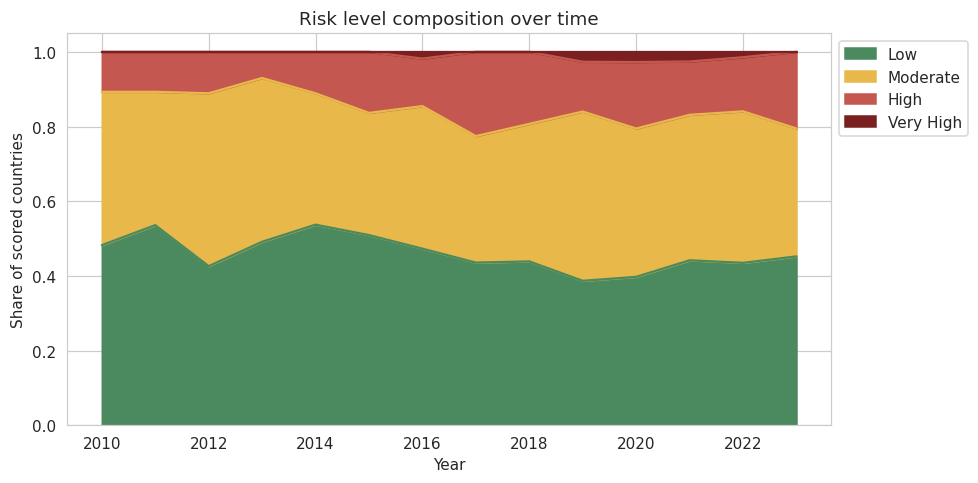

In [7]:
order = ["Low", "Moderate", "High", "Very High"]

yearly = complete[complete["risk_level"].isin(order)].copy()
yearly["risk_level"] = pd.Categorical(yearly["risk_level"], categories=order, ordered=True)

level_counts = yearly.groupby(["Year", "risk_level"], observed=True).size().unstack(fill_value=0)
level_share = level_counts.div(level_counts.sum(axis=1), axis=0)

fig, ax = plt.subplots(figsize=(9, 4.5))
level_share[order].plot(kind="area", ax=ax, stacked=True,
                          color=["#4b8a5e", "#e8b84b", "#c45850", "#7a2020"])
ax.set_ylabel("Share of scored countries")
ax.set_title("Risk level composition over time")
ax.legend(loc="upper left", bbox_to_anchor=(1.0, 1.0))
plt.tight_layout()
plt.savefig("risk_level_composition.png", dpi=150, bbox_inches="tight")
plt.show()


"Low" stays the largest bucket throughout — the risk-level mix hasn't
shifted dramatically, consistent with the balanced-panel finding above.
"Very High" stays a thin sliver every year (never more than 8 countries) —
this remains a tail-risk story, not a broad-based one.

## Summary

In [8]:
print("Countries scored: 56 (2010) to 73 (2023)")
print("Full-sample mean risk trend: 0.276 -> 0.320 (looks like +16%)")
print("Balanced-panel mean risk trend (27 countries, all 14 years): 0.251 -> 0.263 (~flat)")
print()
print("Biggest riser: Kazakhstan (0.09 -> 0.66), also the most volatile country")
print("Biggest fallers: Hungary, Guatemala")
print("Wheat and maize consistently score above rice across all years")
print("'Very High' risk_level stays a small tail (<=8 countries) every year")


Countries scored: 56 (2010) to 73 (2023)
Full-sample mean risk trend: 0.276 -> 0.320 (looks like +16%)
Balanced-panel mean risk trend (27 countries, all 14 years): 0.251 -> 0.263 (~flat)

Biggest riser: Kazakhstan (0.09 -> 0.66), also the most volatile country
Biggest fallers: Hungary, Guatemala
Wheat and maize consistently score above rice across all years
'Very High' risk_level stays a small tail (<=8 countries) every year


**Caveat carried over from Analysis 2:** this covers the 873 country-years
with all three staples and all three risk components present — about 46%
of the full panel. Trends here describe that scored subset, not the full
168-country universe.